[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IbHansen/wb-debt-simulation/blob/main/optimization/kes/currency%20info.ipynb)

In [1]:
if 'google.colab' in str(get_ipython()):
    import os
    os.system('pip -qqq install ModelFlowIb openpyxl')
    os.system(
        'curl -sL -o exchangerates_get.py '
        'https://raw.githubusercontent.com/IbHansen/wb-debt-simulation/main/'
        'optimization/exchangerates_get.py'
    )
    os.system(
        'curl -sL -o get_kes.py '
        'https://raw.githubusercontent.com/IbHansen/wb-debt-simulation/main/'
        'optimization/kes/get_kes.py'
    )
    os.makedirs('currency', exist_ok=True)
    print("Please upload 'kes_wide.xlsx' when the file picker appears:")
    from google.colab import files
    uploaded = files.upload()
    for fn in uploaded:
        import shutil; shutil.move(fn, f'currency/{fn}')


In [2]:
import sys
from pathlib import Path
# Make exchangerates_get (in the parent folder) importable when running locally
if str(Path('..').resolve()) not in sys.path:
    sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import numpy as np
import exchangerates_get as er
from get_kes import get_kes_iso


In [3]:
# Load KES FX rates and convert to KES-as-base convention.
# get_kes_iso() reads currency/kes_wide.xlsx, inverts CBK rates
# (USD_KES -> KES_USD etc.) and resamples to quarterly frequency --
# identical pipeline to ecb_fx_eur + convert_base_currency(base='kes').
fx_ccy = get_kes_iso(
    currencies=['USD', 'GBP', 'EUR', 'JPY', 'CNY'],
    start='2016-01-01',
    freq='QE',
    agg='last',
)

fx_returns = er.get_fx_returns(fx_ccy)

# Annualised covariance: quarterly cov x 4
fx_cov = er.get_fx_covariance(fx_returns, periods_per_year=4)


In [4]:
fx_ccy

,KES_USD,KES_GBP,KES_EUR,KES_JPY,KES_CNY
date,,,,,
2016Q4,0.009757,0.007973,0.009341,0.011486,0.067878
2017Q1,0.009709,0.007762,0.009045,0.010797,0.066896
2017Q2,0.009642,0.007429,0.008452,0.010872,0.065412
2017Q3,0.009685,0.007214,0.008219,0.010906,0.064544
2017Q4,0.009687,0.007207,0.008112,0.010931,0.063309
2018Q1,0.009916,0.007027,0.008017,0.010539,0.062450
2018Q2,0.009896,0.007570,0.008557,0.010912,0.065496
2018Q3,0.009905,0.007548,0.008483,0.011199,0.068221
2018Q4,0.009819,0.007751,0.008588,0.010837,0.067531


In [5]:
import numpy as np

fx_corr = er.get_fx_covariance(fx_returns, correlation=True)

# fx_cov is annualised (quarterly × 4) → std here is annual std
std = np.sqrt(np.diag(fx_cov.values))
std = pd.Series(std * 100, index=fx_cov.index, name="Annual std (%)")
print("Annual std (%) — note: quarterly std × 2 = annual std:")
print(std.to_string())
print()
print("Annual covariance matrix:")
display(fx_cov)

Annual std (%) — note: quarterly std × 2 = annual std:
KES_USD     7.323725
KES_GBP    11.346920
KES_EUR    11.228220
KES_JPY    13.112054
KES_CNY     8.913074

Annual covariance matrix:


,KES_USD,KES_GBP,KES_EUR,KES_JPY,KES_CNY
KES_USD,0.005364,0.004932,0.005636,0.006169,0.005108
KES_GBP,0.004932,0.012875,0.011750,0.011396,0.008563
KES_EUR,0.005636,0.011750,0.012607,0.012483,0.008612
KES_JPY,0.006169,0.011396,0.012483,0.017193,0.009573
KES_CNY,0.005108,0.008563,0.008612,0.009573,0.007944


KES_USD     732.372544
KES_GBP    1134.691956
KES_EUR    1122.822020
KES_JPY    1311.205385
KES_CNY     891.307423
Name: Annual std (%), dtype: float64


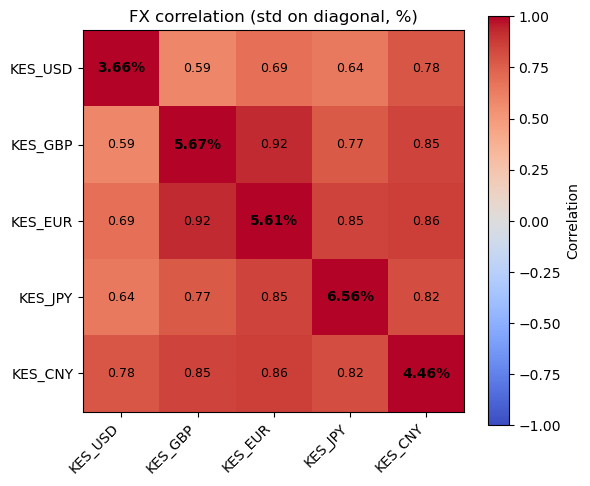

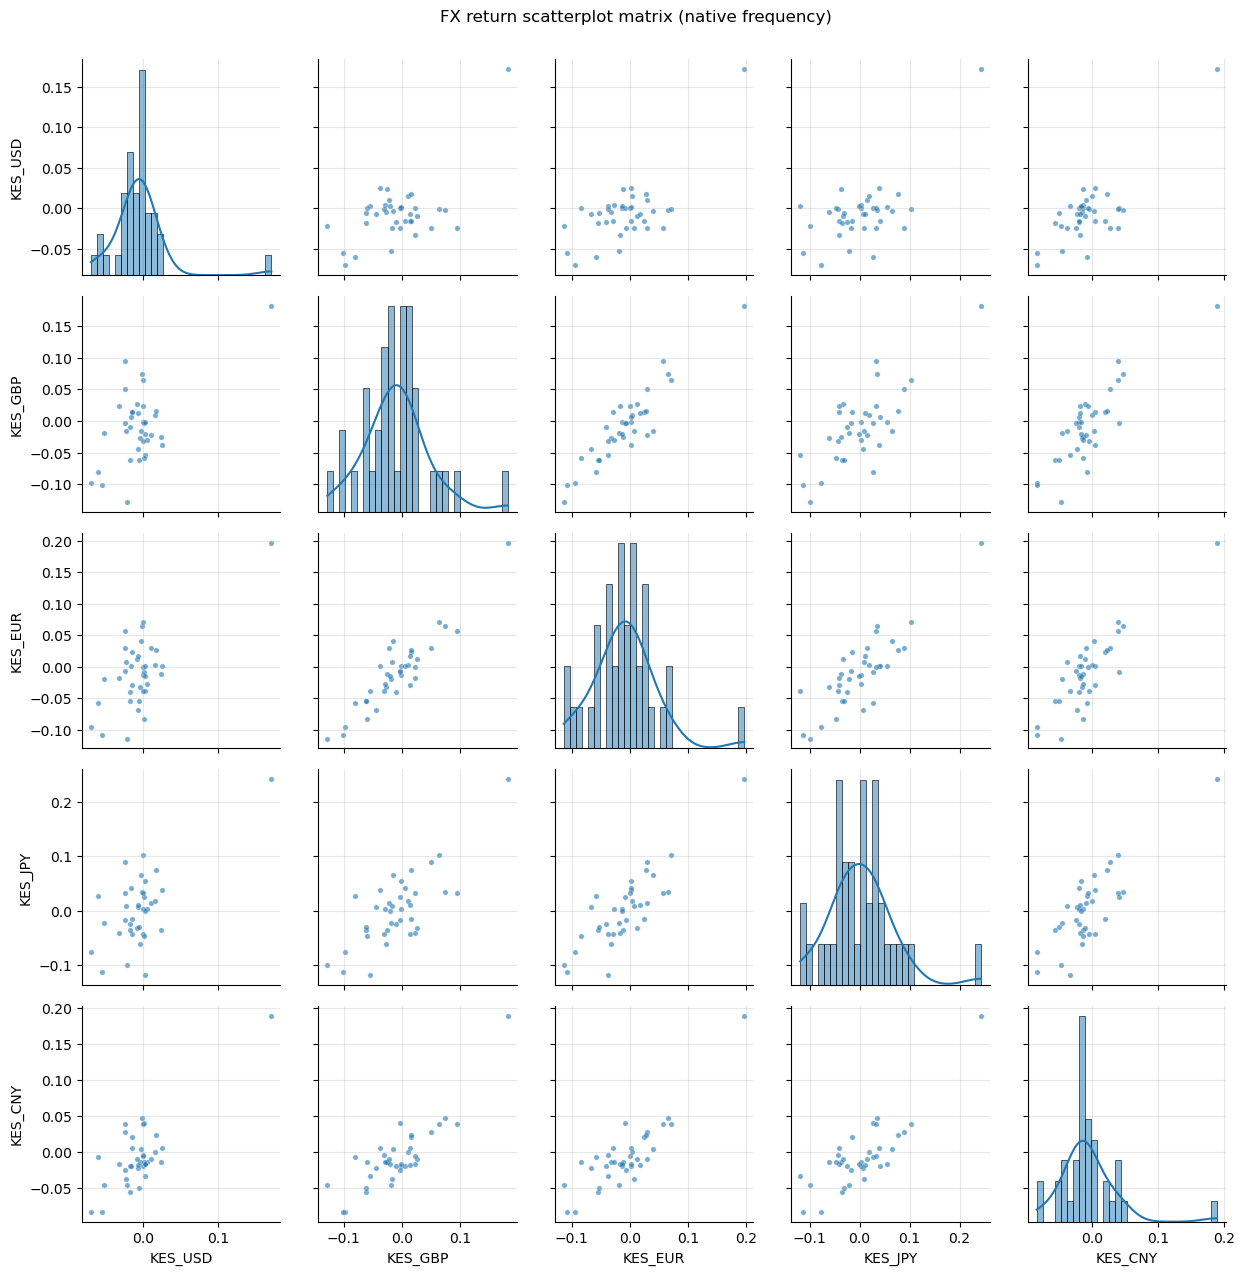

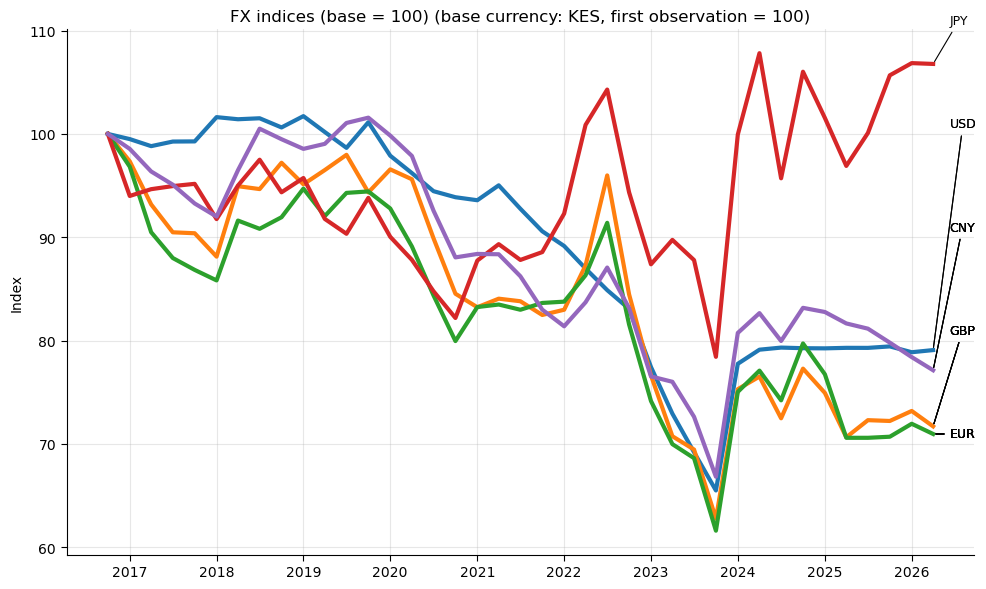

In [6]:
print(std*100)

er.plot_corr_with_std(
    fx_returns,
    title="FX correlation (std on diagonal, %)"
)


er.plot_return_scatter_matrix_with_marginals(
    fx_returns,
    title="FX return scatterplot matrix (native frequency)"
)
#%%
er.plot_indexed_fx(
    fx_ccy,
    min_label_gap=10.0

)

In [7]:
# Strip 'KES_' prefix so the optimiser index is just the currency code
cov_df = fx_cov.rename(
    index=lambda x: x.split('_')[1],
    columns=lambda x: x.split('_')[1],
)
names = cov_df.index
n = len(names)

# Approximate sovereign borrowing costs (annual) from a KES perspective.
# Adjust to reflect current market conditions or your own assumptions.
interest_rates = {
    'USD': 0.043,
    'GBP': 0.045,
    'EUR': 0.025,
    'JPY': 0.005,
    'CNY': 0.025,
}

assumptions = pd.DataFrame(
    {
        'interest_rate':         [interest_rates.get(c, 0.03) for c in names],
        'expected_appreciation': [0.0] * n,
        'min_share':             [0.0] * n,
        'max_share':             [1.0] * n,
        'current_share':         [1.0 / n] * n,
    },
    index=names,
)
assumptions


,interest_rate,expected_appreciation,min_share,max_share,current_share
USD,0.043,0.0,0.0,1.0,0.2
GBP,0.045,0.0,0.0,1.0,0.2
EUR,0.025,0.0,0.0,1.0,0.2
JPY,0.005,0.0,0.0,1.0,0.2
CNY,0.025,0.0,0.0,1.0,0.2


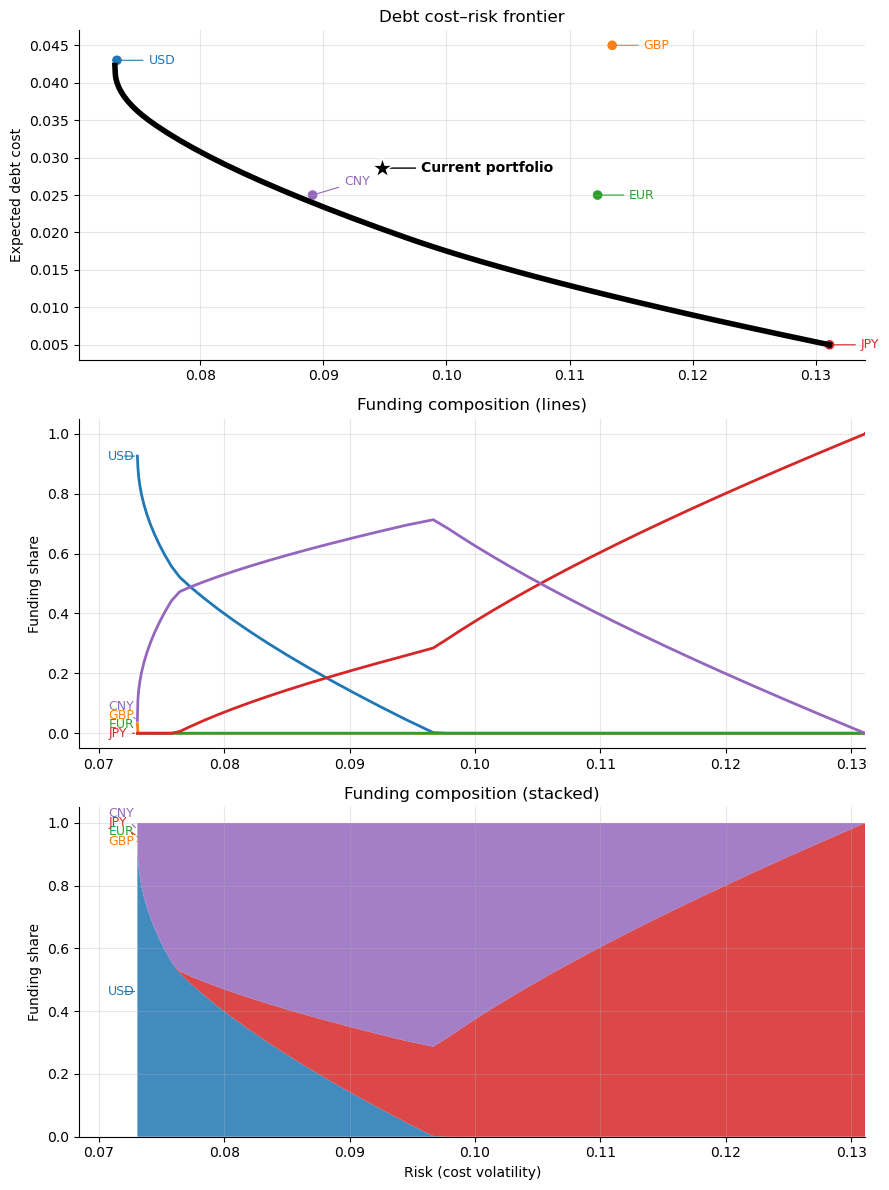

In [8]:
res = er.mv_from_dataframes(cov_df=cov_df, assumptions=assumptions)
expected_cost = assumptions['interest_rate'] + assumptions['expected_appreciation']

er.plot_debt_frontier_labeled(
    res.iloc[1:].reset_index(drop=True),
    label_pos='start',
    cost_col='return',
    cost_s=expected_cost,
    cov_df=cov_df,
    current=res.iloc[0],
    export_path='kes_debt_frontier',
    export_formats=('png', 'pdf', 'svg'),
)


## Interactive inputs -- `DebtFrontierInputs`

Edit the assumption grid and press **Run frontier** to re-solve and re-plot.
The `assumptions` attribute always reflects the latest edits.

In [9]:
inputs = er.DebtFrontierInputs(cov_df=cov_df, assumptions=assumptions)
inputs.assumptions

,interest_rate,expected_appreciation,min_share,max_share,current_share
USD,0.043,0.0,0.0,1.0,0.2
GBP,0.045,0.0,0.0,1.0,0.2
EUR,0.025,0.0,0.0,1.0,0.2
JPY,0.005,0.0,0.0,1.0,0.2
CNY,0.025,0.0,0.0,1.0,0.2


In [10]:
inputs.widget()